1. Сначала познакомимся с простой линейной моделью и задачей подгонки прямой под облако точек.
Для этого нужно сгенерировать модельные данные: массив X, где Xk = k/m для m = 10, 20, 50,
и массив Y, где Yi = aXi + b + εi, где a, b – количество гласных в ваших имени и фамилии соответственно, случайные величины εi ∼ N (0, σ2) независимы (используйте σ = 1, σ = a/9).

(a) Найти оценки для коэффициентов прямой методом МНК (см. регрессия, OLS).

(b) Построить на одном графике облако точек, полученную прямую, исходную прямую.

(c) Сравнить полученные коэффициенты и оценку дисперсии ошибок с исходными.

Настоящие парметры 4, 3, σ = 1 полученные их оценки 4.789259891041672, 2.468678843655078, дисперсия отклонений 1.0869341849264642


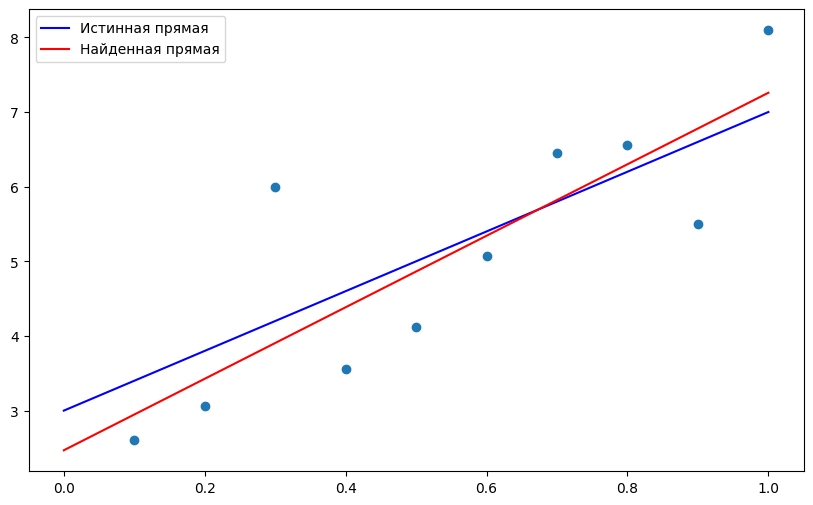

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 3.212353778319302, 3.4871953174129, дисперсия отклонений 0.18667424936916102


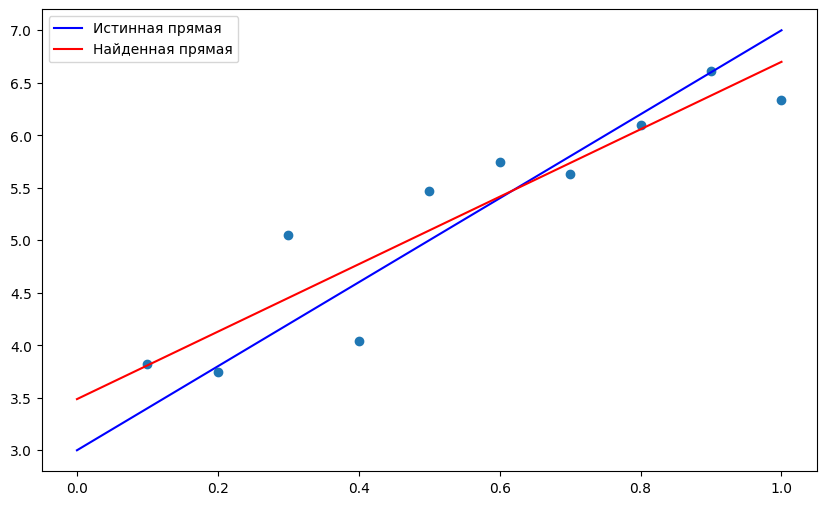

Настоящие парметры 4, 3, σ = 1 полученные их оценки 4.536734460074043, 2.9742713817131428, дисперсия отклонений 0.6352450244277391


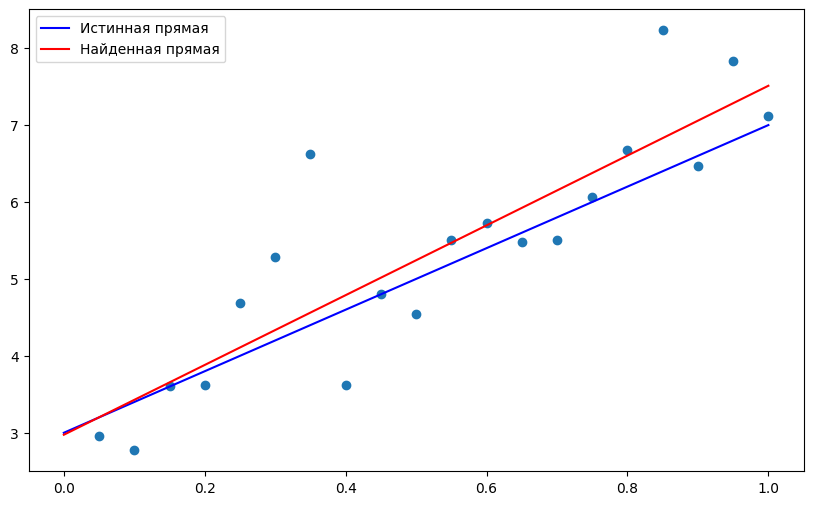

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 4.280361374262846, 2.788956693103366, дисперсия отклонений 0.24110323118298357


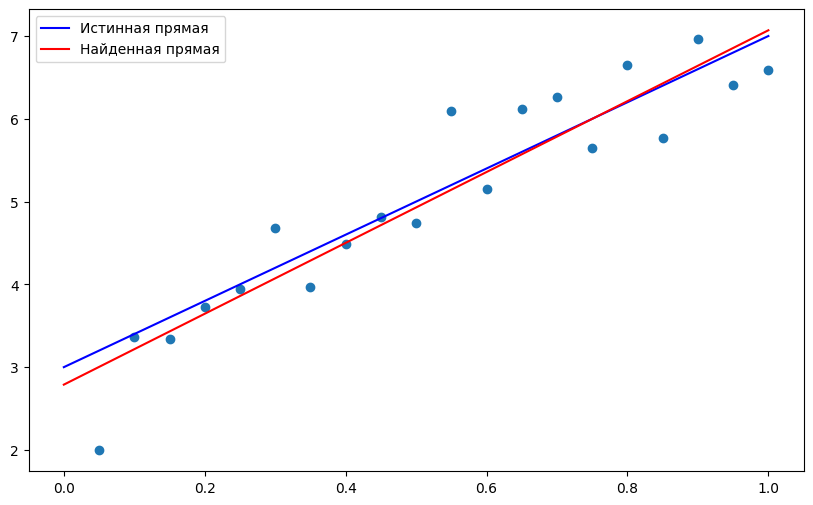

Настоящие парметры 4, 3, σ = 1 полученные их оценки 3.364370210115276, 3.322222418024869, дисперсия отклонений 0.8089586830249011


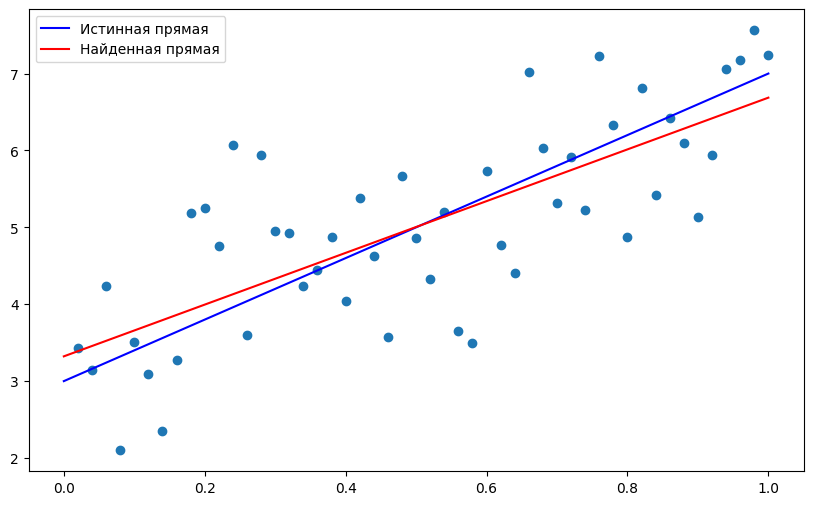

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 4.023599042050135, 3.0203692284675423, дисперсия отклонений 0.18868430684952717


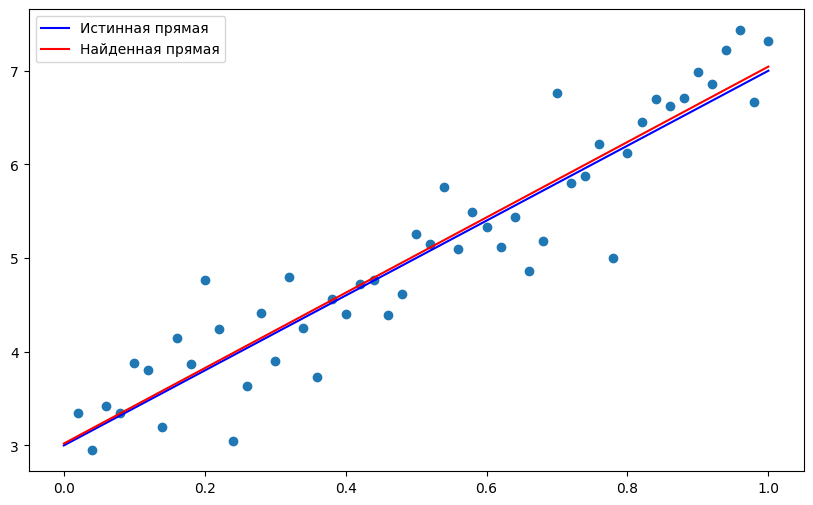

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def method_of_least_squares(m_values, a, b, σ_values):
    X_line = np.linspace(0, 1, 100)
    for m in m_values:
        X = np.arange(1, m+1) / m
        for σ in σ_values:
            ε_sample = np.random.normal(0, σ, m)     #Мы знаем, что Х верный, ошибка в У, смещение иы смортим по нему 
            Y = a * X + b + ε_sample
            X_mean = np.mean(X)
            Y_mean = np.mean(Y)
            a_est = np.sum((X - X_mean)*(Y - Y_mean)) / np.sum((X - X_mean)**2)
            b_est = Y_mean - a_est * X_mean
            residuals = Y - (a_est * X + b_est) #вертикальные расстояния до идеальной прямой
            var_est = np.sum(residuals**2) / (m - 2) #насколько мы вообще угадали с этой идефльной прямой - какой разброс
            print(f"Настоящие парметры {a}, {b}, σ = {σ} полученные их оценки {a_est}, {b_est}, дисперсия отклонений {var_est}")
            plt.figure(figsize=(10,6))
            plt.scatter(X, Y)
            plt.plot(X_line, a * X_line + b, color = 'blue', label = 'Истинная прямая')
            plt.plot(X_line, a_est * X_line + b_est, color = 'red', label = 'Найденная прямая')
            plt.legend()
            plt.show()
            
m_values = [10, 20, 50]
a = 4
b = 3
σ_values = [1, a/9]
method_of_least_squares(m_values, a, b, σ_values)

2. Теперь посмотрим, как наши методы реагируют на сильно отклоняющиеся от прямой значения Y .
Для этого в массиве Y нужно изменить несколько элементов.

(a) Пусть Yt = aXt + b + 5σ для некоторого (одного!) t. Построить новую прямую методом МНК,
сравнить с прямой МНК, построенной в задаче 1. Рассмотреть случаи, когда Xt находится в
центре массива и когда Xt расположен на краю.

(b) Если Yt = aXt +b+5σ, а Ys = aXs +b−5σ, будут ли эти выбросы компенсировать друг друга?
Рассмотреть случаи, когда Xt, Xs находятся а) рядом б) на разных концах ряда.

Настоящие парметры 4, 3, σ = 1 полученные их оценки 3.9757469600380033, 2.961808116293208, дисперсия отклонений 0.6827065224769326


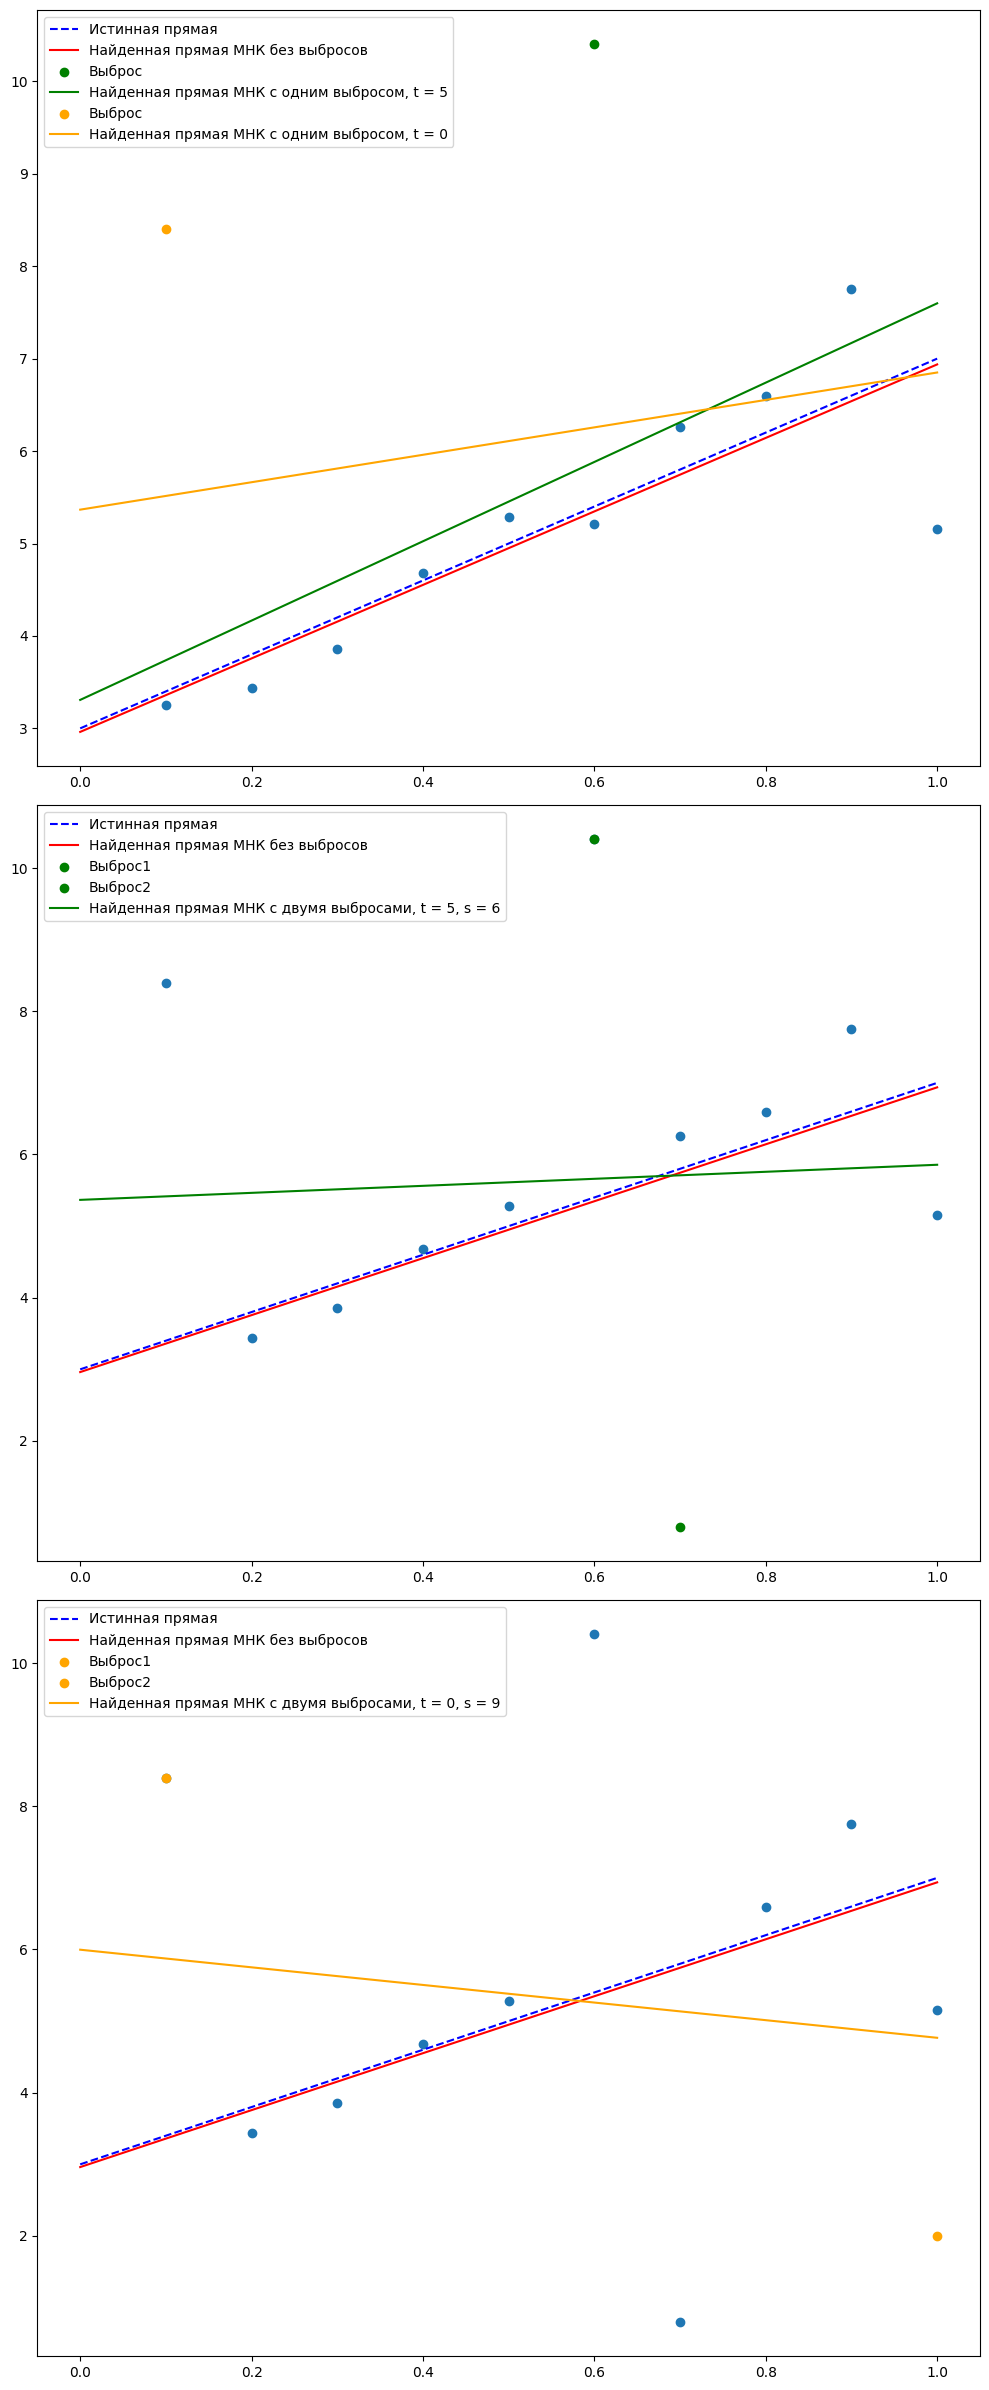

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 4.484352232946161, 2.7592469608447026, дисперсия отклонений 0.21462664378650836


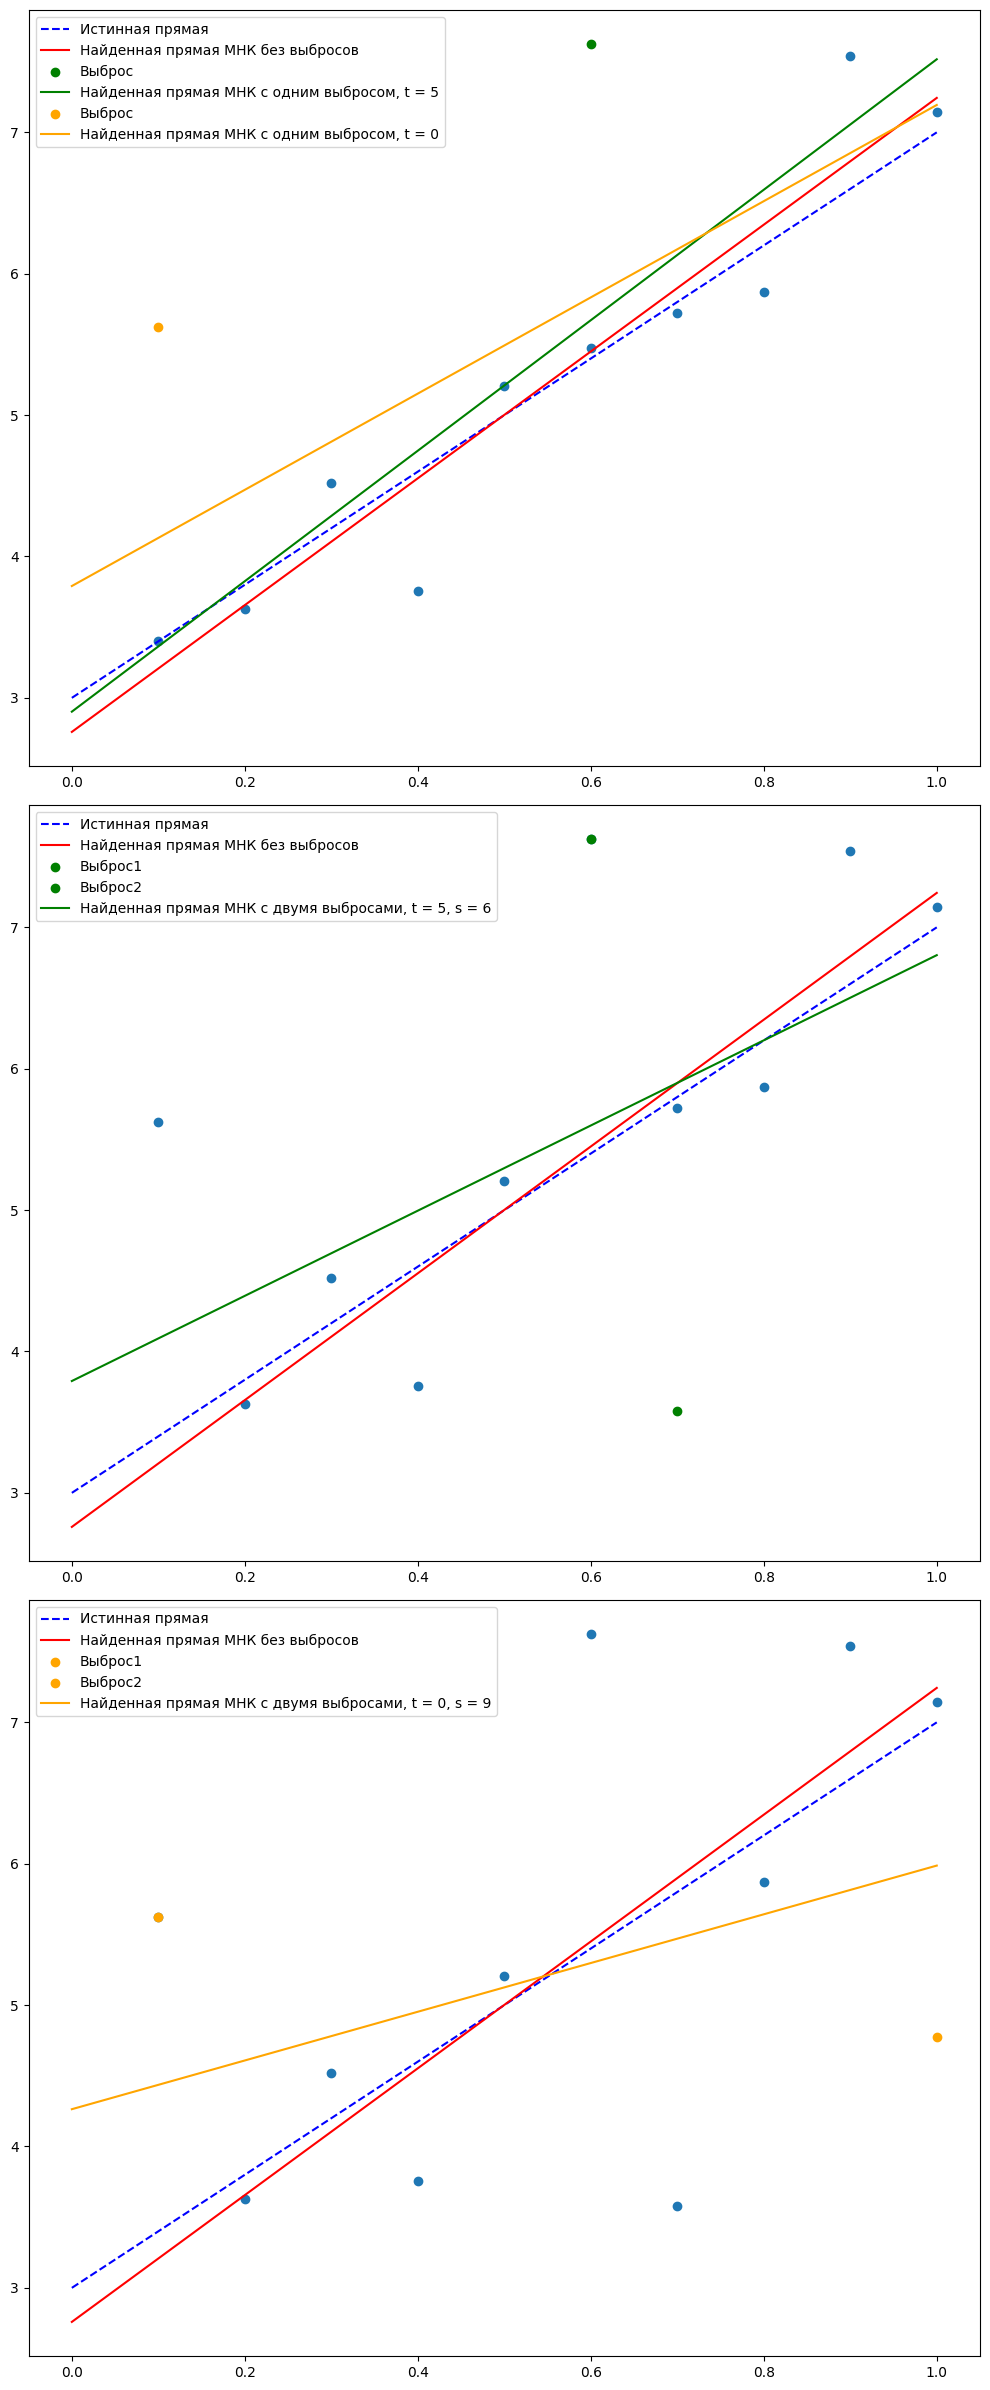

Настоящие парметры 4, 3, σ = 1 полученные их оценки 5.34820078699401, 2.389143975437154, дисперсия отклонений 0.682312728559816


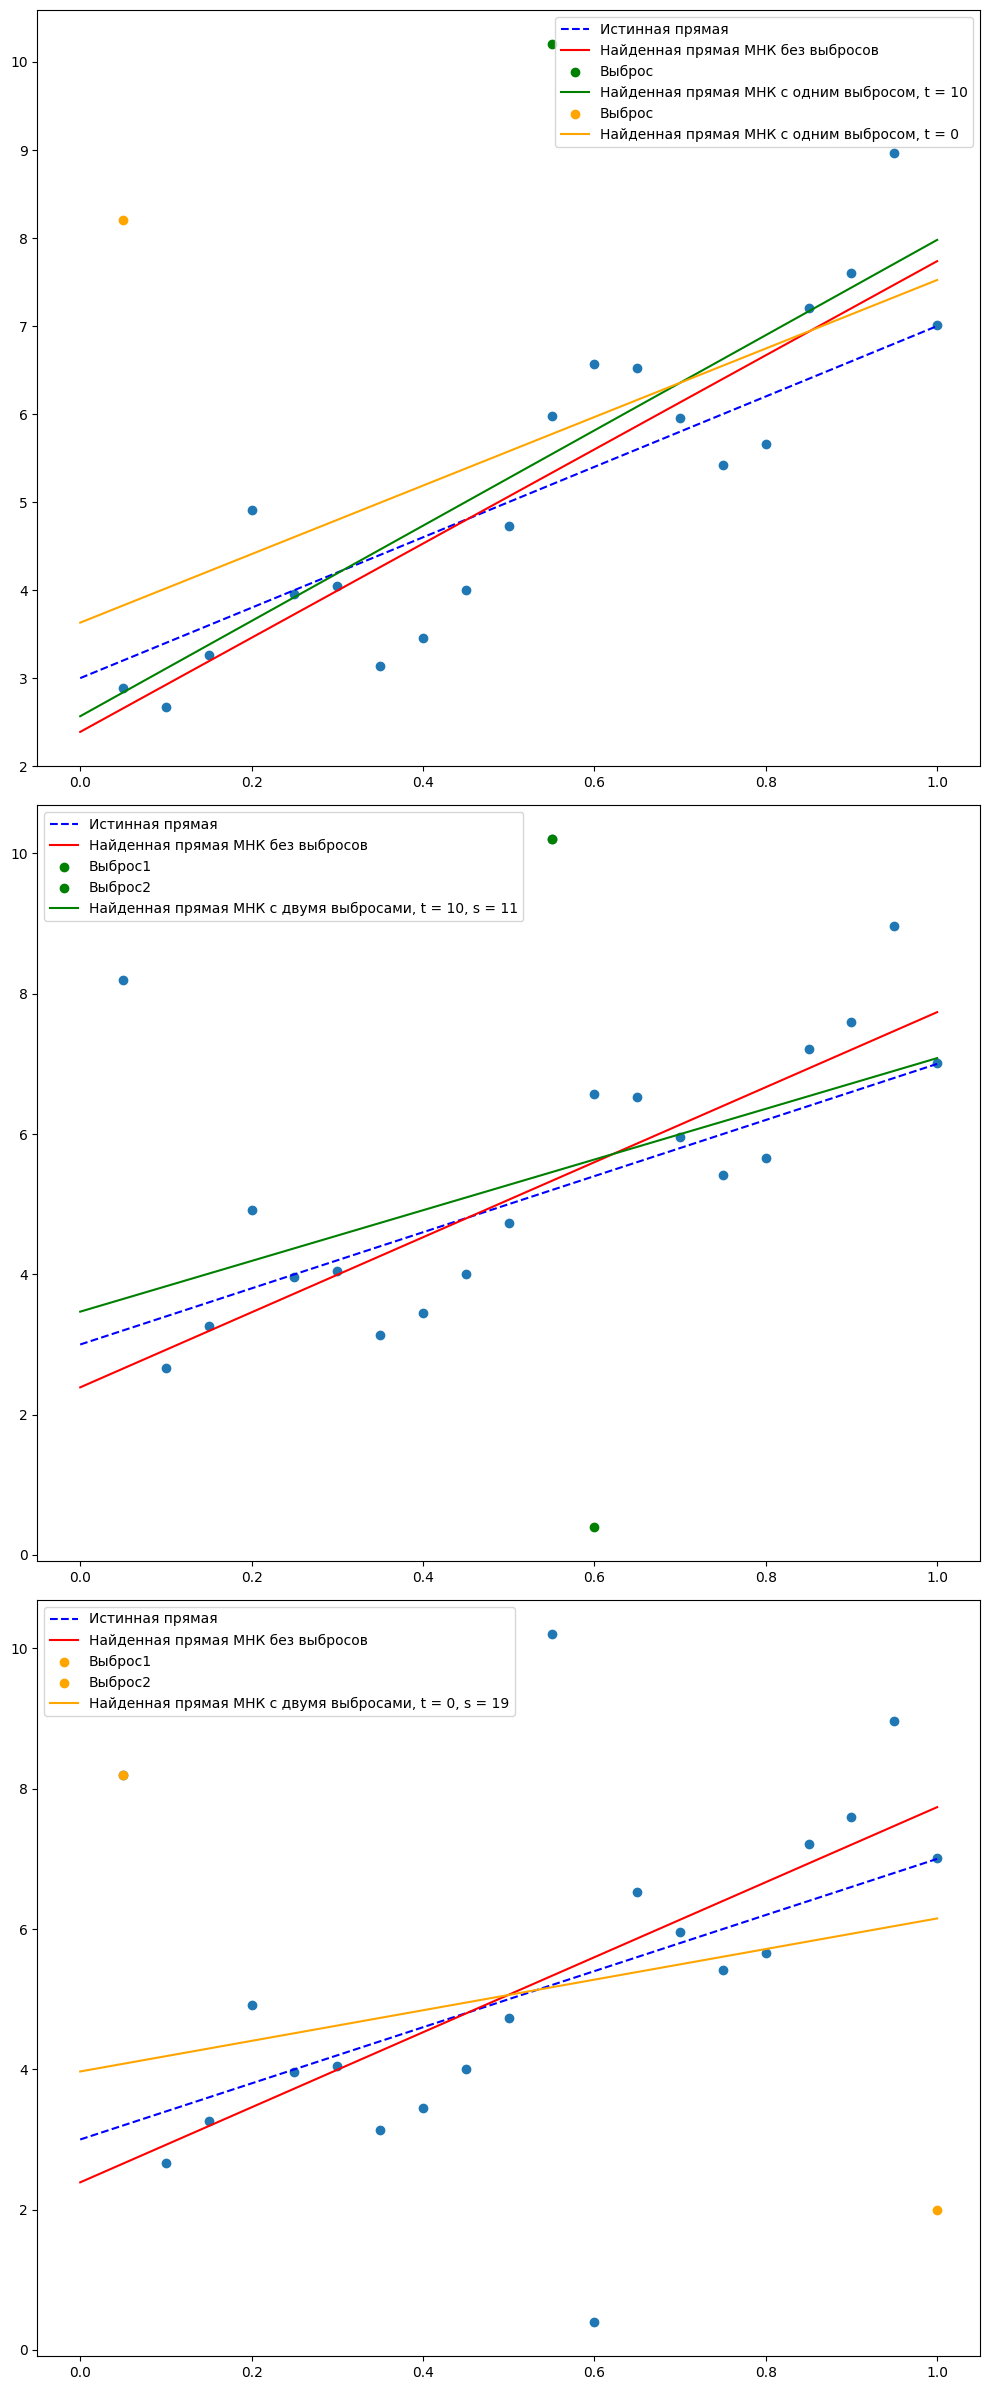

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 3.6022756634672177, 3.1510659467019932, дисперсия отклонений 0.25353174678355606


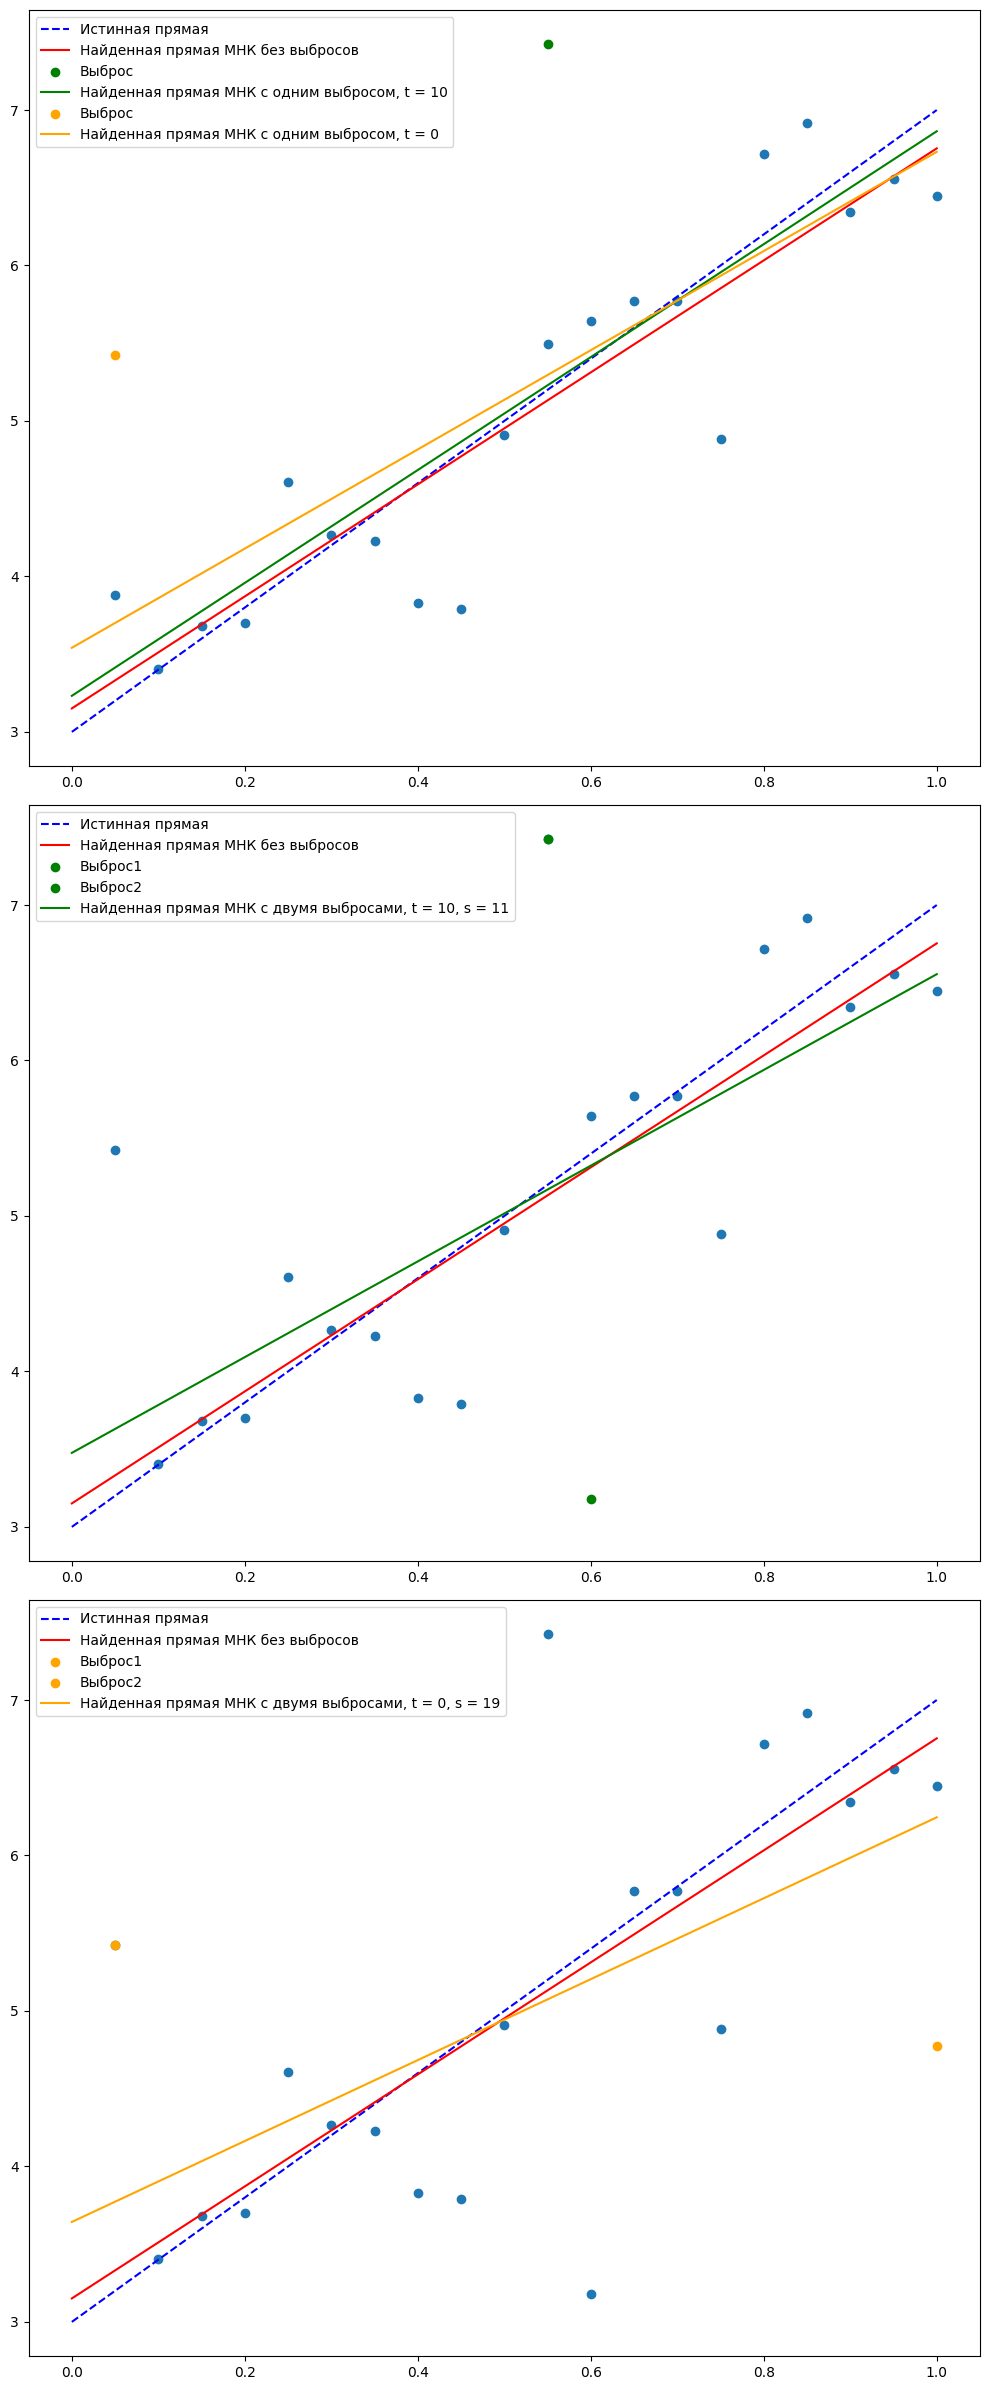

Настоящие парметры 4, 3, σ = 1 полученные их оценки 4.128985732479802, 2.9144283070479444, дисперсия отклонений 1.268351018655298


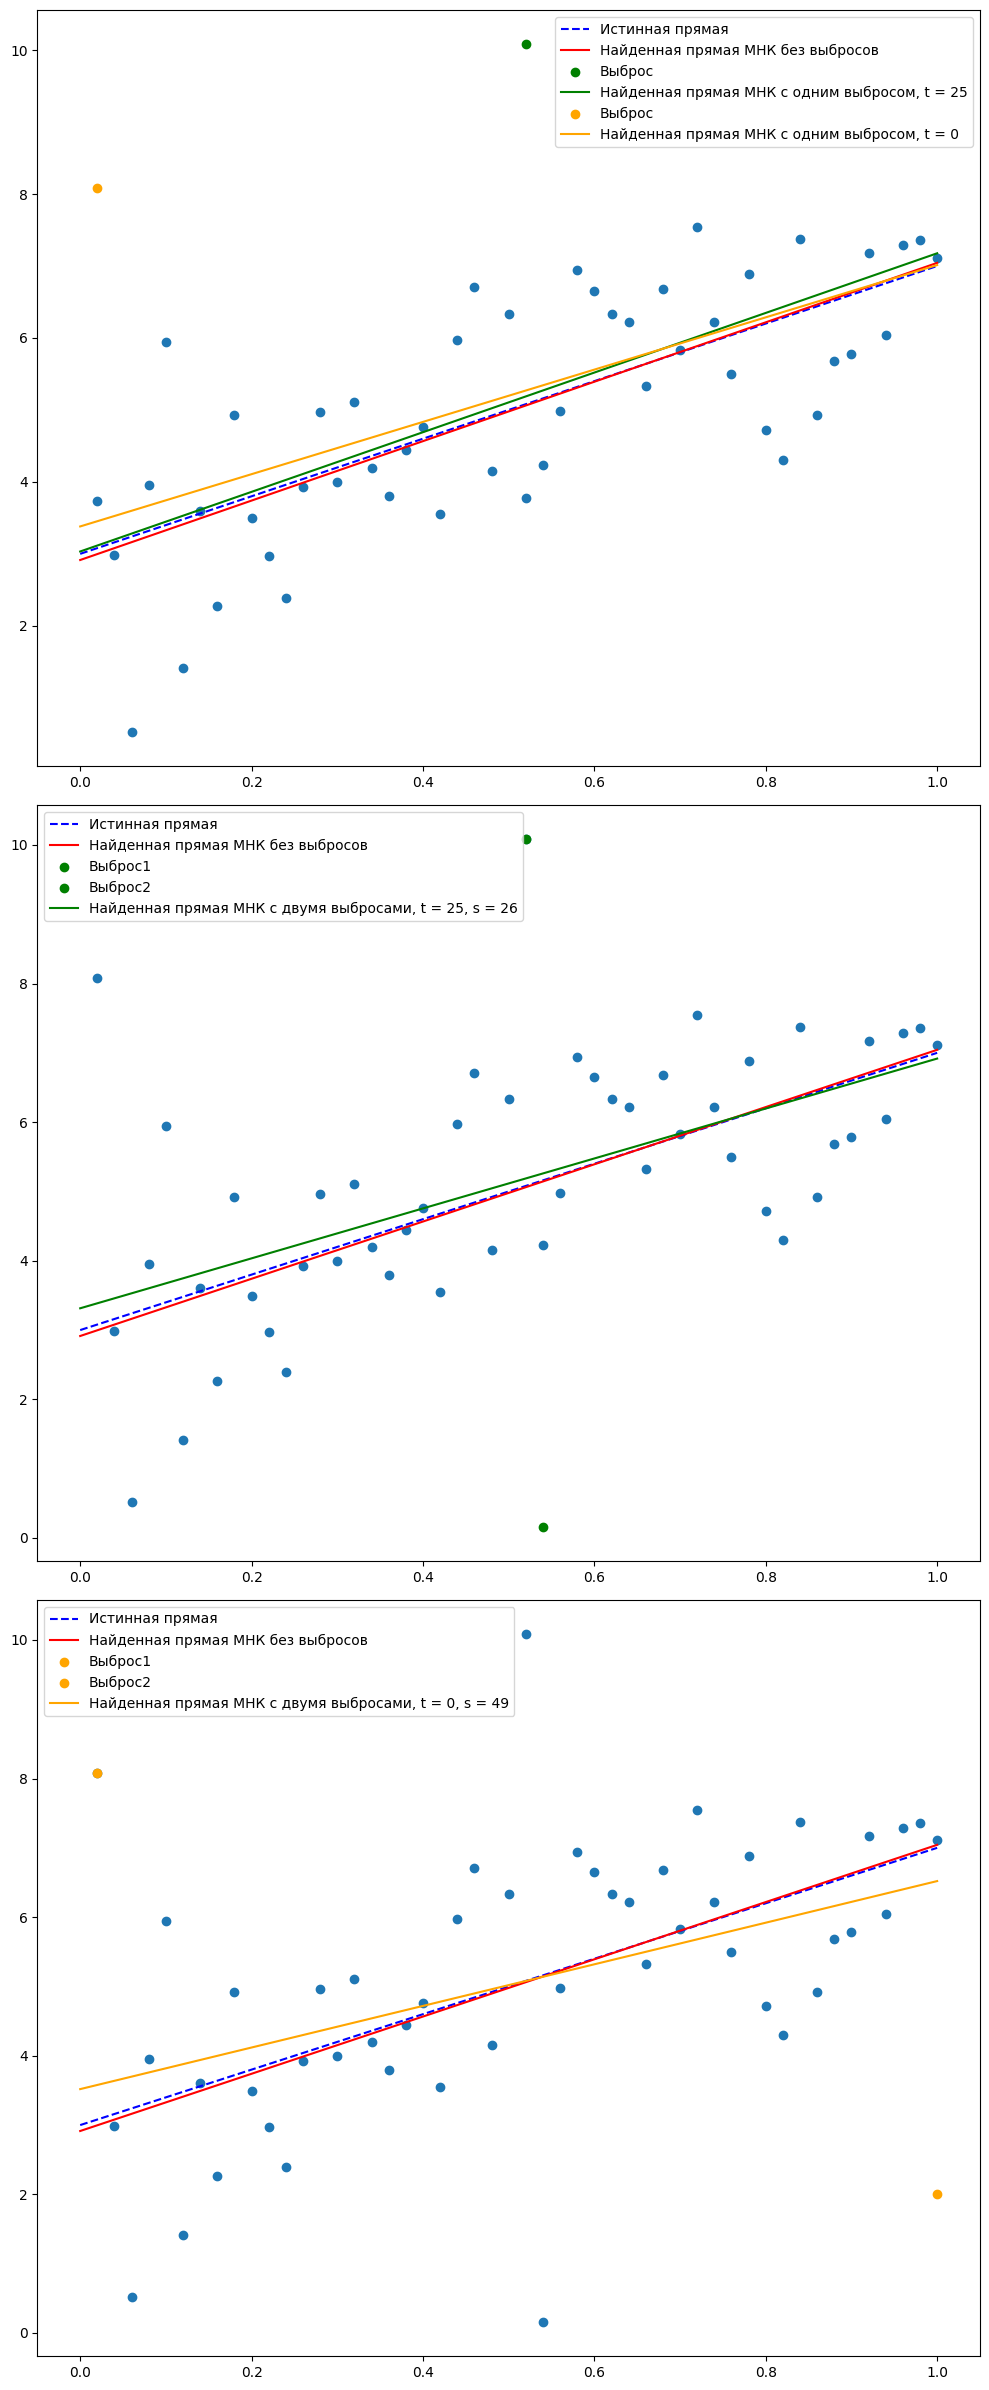

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 4.173854070216436, 2.912869301535679, дисперсия отклонений 0.13556766242721308


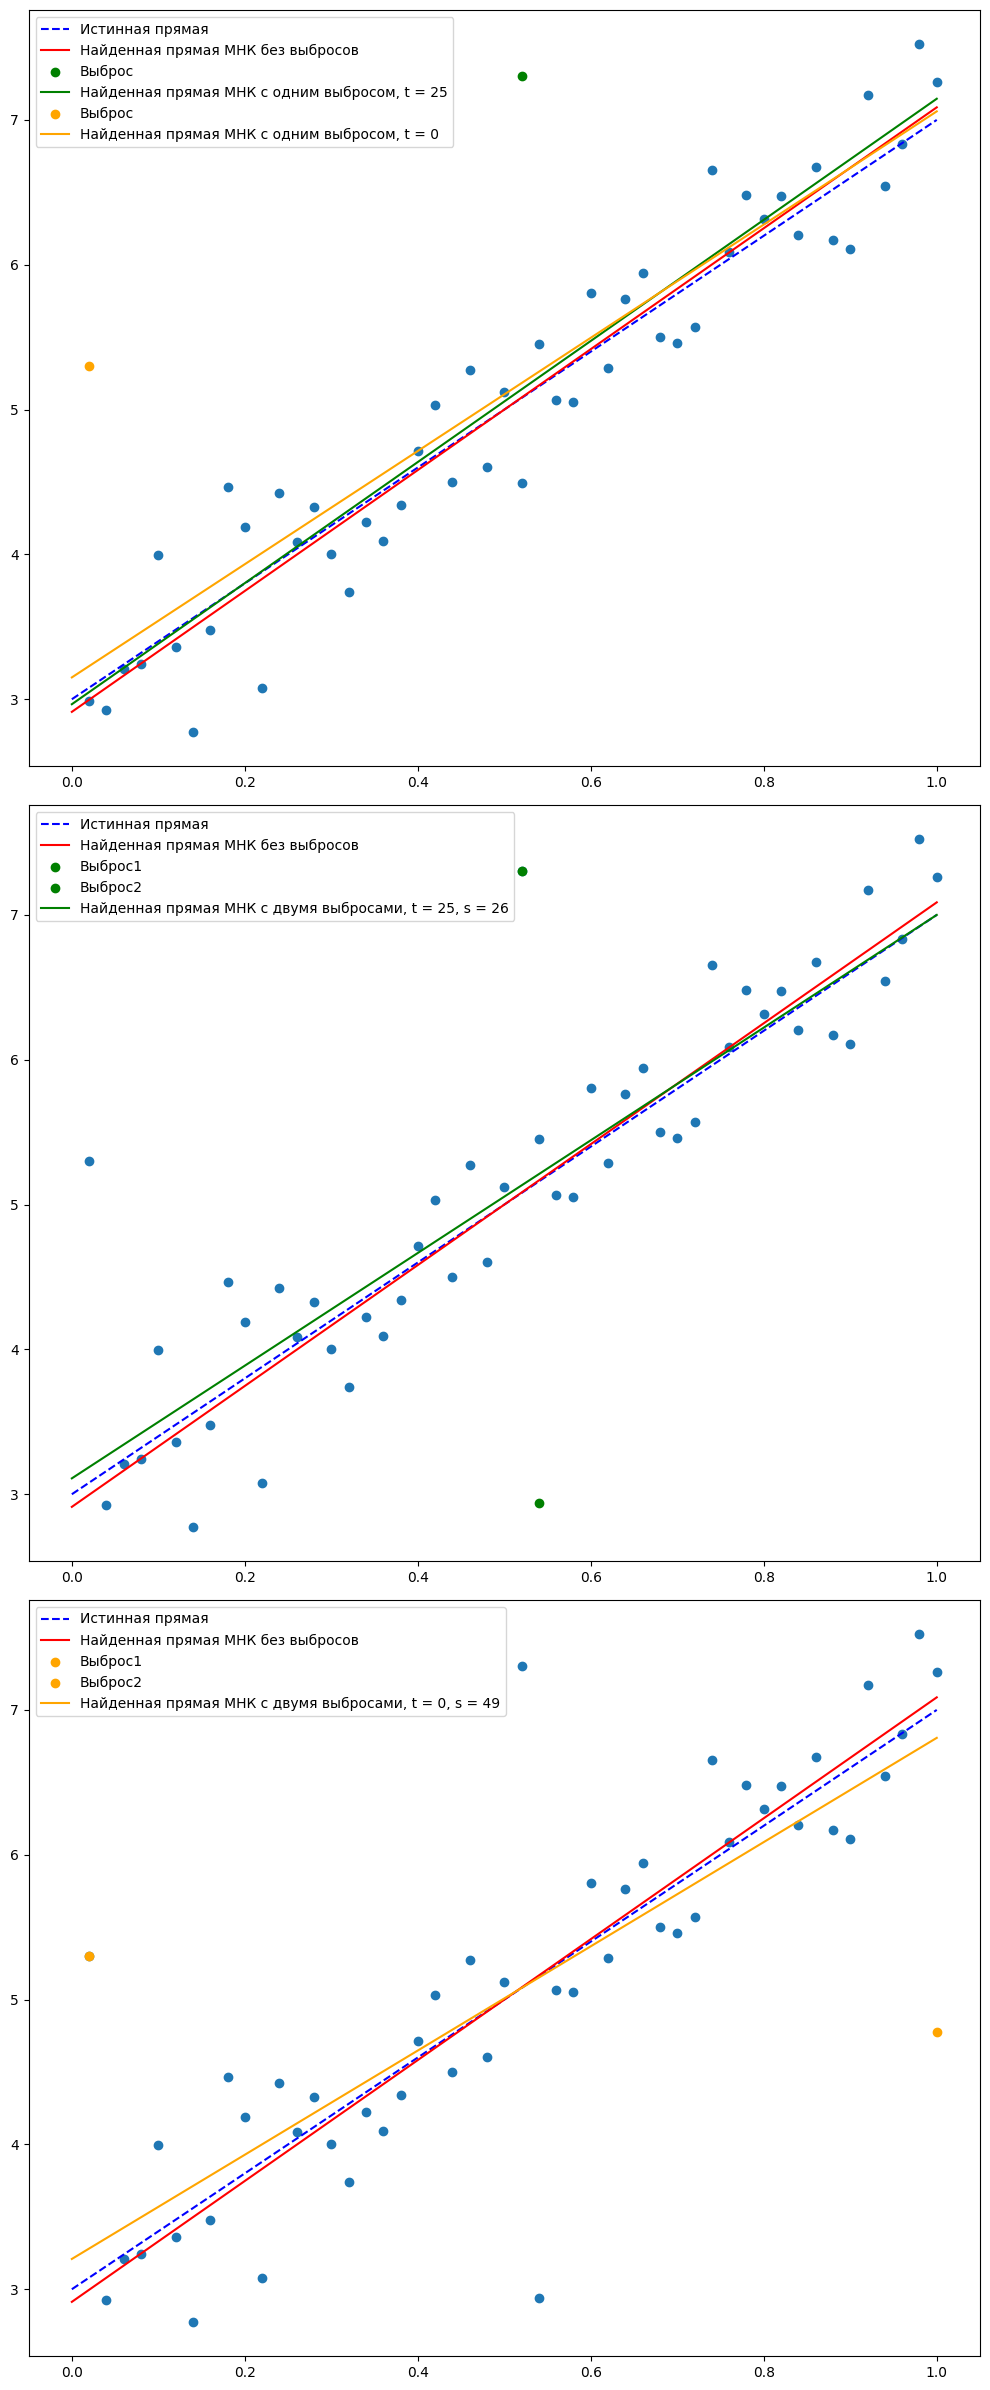

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def method_of_least_squares(m_values, a, b, σ_values):
    X_line = np.linspace(0, 1, 100)
    for m in m_values:
        X = np.arange(1, m+1) / m
        t_values = [m // 2, 0]
        for σ in σ_values:
            ε_sample = np.random.normal(0, σ, m)     #Мы знаем, что Х верный, ошибка в У, смещение иы смортим по нему 
            Y = a * X + b + ε_sample
            X_mean = np.mean(X)
            Y_mean = np.mean(Y)
            a_est = np.sum((X - X_mean)*(Y - Y_mean)) / np.sum((X - X_mean)**2)
            b_est = Y_mean - a_est * X_mean
            residuals = Y - (a_est * X + b_est) #вертикальные расстояния до идеальной прямой
            var_est = np.sum(residuals**2) / (m - 2) #насколько мы вообще угадали с этой идефльной прямой - какой разброс
            print(f"Настоящие парметры {a}, {b}, σ = {σ} полученные их оценки {a_est}, {b_est}, дисперсия отклонений {var_est}, размер выборки m = {m}")
            plt.figure(figsize=(10,24))
            plt.subplot(3, 1, 1)
            plt.scatter(X, Y)
            plt.plot(X_line, a * X_line + b, '--', color = 'blue', label = 'Истинная прямая')
            plt.plot(X_line, a_est * X_line + b_est, color = 'red', label = 'Найденная прямая МНК без выбросов')
            OLS_with_one_outlier(X_line, X_mean, σ, t_values, X, Y)
            OLS_with_two_outlier(X_line, X_mean, σ, t_values, X, Y, m, a_est, b_est)
            plt.tight_layout()
            plt.show()
            
def OLS_with_one_outlier(X_line, X_mean, σ, t_values, X, Y):
    colors = ['green', 'orange']
    for i, t in enumerate(t_values):
        Y[t] =  a * X[t] + b + 5 * σ
        Y_mean = np.mean(Y)
        a_one_out = np.sum((X - X_mean)*(Y - Y_mean)) / np.sum((X - X_mean)**2)
        b_one_out = Y_mean - a_one_out * X_mean
        plt.scatter(X[t], Y[t], color = colors[i], label='Выброс')
        plt.plot(X_line, a_one_out * X_line + b_one_out, color = colors[i], label = f'Найденная прямая МНК с одним выбросом, t = {t}')
        plt.legend()
        
def OLS_with_two_outlier(X_line, X_mean, σ, t_values, X, Y, m, a_est, b_est):
    colors = ['green', 'orange']
    for i, t in enumerate(t_values):
        plt.subplot(3, 1, i+2)
        plt.scatter(X, Y)
        plt.plot(X_line, a * X_line + b, '--', color = 'blue', label = 'Истинная прямая')
        plt.plot(X_line, a_est * X_line + b_est, color = 'red', label = 'Найденная прямая МНК без выбросов')
        Y[t] =  a * X[t] + b + 5 * σ
        plt.scatter(X[t], Y[t], color = colors[i], label='Выброс1')
        if i == 0:
            Y[t + 1] = a * X[t + 1] + b - 5 * σ
            plt.scatter(X[t+1], Y[t+1], color = colors[i], label='Выброс2')
            Y_mean = np.mean(Y)
            a_two_out = np.sum((X - X_mean)*(Y - Y_mean)) / np.sum((X - X_mean)**2)
            b_two_out = Y_mean - a_two_out * X_mean
            plt.plot(X_line, a_two_out * X_line + b_two_out, color = colors[i], label = f'Найденная прямая МНК с двумя выбросами, t = {t}, s = {t+1}')
            plt.legend()
        else:
            Y[m - 1] = a * X[m - 1] + b - 5 * σ
            plt.scatter(X[m-1], Y[m-1], color = colors[i], label='Выброс2')
            Y_mean = np.mean(Y)
            a_two_out = np.sum((X - X_mean)*(Y - Y_mean)) / np.sum((X - X_mean)**2)
            b_two_out = Y_mean - a_two_out * X_mean
            plt.plot(X_line, a_two_out * X_line + b_two_out, color = colors[i], label = f'Найденная прямая МНК с двумя выбросами, t = {t}, s = {m-1}')
            plt.legend()
   

m_values = [10, 20, 50]
a = 4
b = 3
σ_values = [1, a/9]
method_of_least_squares(m_values, a, b, σ_values)